# 1D-CNN Time-Series Model for Harsh Driving Event Detection

This notebook implements a 1D Convolutional Neural Network (CNN) in PyTorch to classify windowed IMU sequence data into driving behavior categories (e.g., sudden acceleration, sudden braking, harsh turns, harsh lane changes, and safe driving).

### Improvements Over Previous Models:
1. **Causal Real-time Architecture:** Uses pure 1D-CNN blocks rather than Bidirectional LSTMs, which avoids lookahead latency and is suitable for streaming real-time inference.
2. **Feature Standardization:** Standardizes sequence features across time and samples using `StandardScaler` fitted on the training set.
3. **Dataset Balancing:** Applies `RandomOverSampler` on the flattened sequence train set to balance minority classes.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import joblib
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
ROOT_DIR = Path("..")
DATASET_DIR = ROOT_DIR / "dataset"
ARTIFACT_DIR = ROOT_DIR / "artifacts"

sys.path.append(str(ROOT_DIR / "src"))
from harsh_event_model import load_row_labeled_data

# Use only accelerometer + gyroscope — magnetometer excluded:
# Training data mag is in real μT scale (~50-600 μT) but CARLA virtual3d
# produces values 10x smaller, so mag features land far outside the
# training distribution after StandardScaler, hurting realtime detection.
imu_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
print("IMU columns (mag EXCLUDED):", imu_cols)


IMU columns (mag EXCLUDED): ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']


## 1. Load Data
Load row-level labeled IMU datasets.

In [3]:
print("Loading raw labeled data...")
raw_df = load_row_labeled_data(DATASET_DIR)
print("Data shape:", raw_df.shape)
print("Label distribution:\n", raw_df["event_label"].value_counts())

Loading raw labeled data...
Data shape: (32043, 16)
Label distribution:
 safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: event_label, dtype: int64


## 2. Apply Light Denoising
Perform rolling median filtering over a short window size of 3.

In [4]:
print("Applying denoising rolling median...")
clean_df = raw_df.copy()
for col in imu_cols:
    clean_df[col] = (
        clean_df.groupby('source_file')[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

Applying denoising rolling median...


## 3. Feature Engineering
Compute calculated stream features (accelerometer/gyroscope magnitudes, jerk, energy ratios, yaw vs roll/pitch relations, etc.).

In [5]:
def add_engineered_features(df):
    df = df.copy()

    # Magnitudes (acc + gyro only)
    df['acc_mag']  = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

    # Jerk
    for axis in ['acc_x', 'acc_y', 'acc_z']:
        df[f'{axis}_jerk'] = df.groupby('source_file')[axis].transform(
            lambda s: s.diff().fillna(0.0)
        )

    # Lateral / longitudinal ratios and energy
    df['lat_long_ratio']        = df['acc_y'].abs() / (df['acc_x'].abs() + 1e-6)
    df['acc_x_abs']             = df['acc_x'].abs()
    df['acc_y_abs']             = df['acc_y'].abs()
    df['gyro_z_abs']            = df['gyro_z'].abs()
    df['acc_lat_energy']        = df['acc_y'] ** 2
    df['acc_long_energy']       = df['acc_x'] ** 2
    df['gyro_yaw_energy']       = df['gyro_z'] ** 2
    df['lat_long_energy_ratio'] = df['acc_y_abs'] / (df['acc_x_abs'] + 1e-6)
    df['turn_vs_lateral']       = df['gyro_z_abs'] / (df['acc_y_abs'] + 1e-6)
    df['yaw_acc_corr']          = df['gyro_z'] * df['acc_y']

    # Differentials
    df['gyro_z_diff'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.diff().fillna(0.0)
    )
    df['acc_y_diff'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.diff().fillna(0.0)
    )

    # Rolling statistics
    for col in ['gyro_z', 'acc_y', 'gyro_x', 'gyro_y']:
        df[f'{col}_roll_std5'] = df.groupby('source_file')[col].transform(
            lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
        )
    df['acc_y_roll_mean5'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )

    # Sign change (oscillation indicator)
    df['gyro_z_sign_change'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: (s.shift(1) * s < 0).astype(int).fillna(0)
    )

    # Roll / pitch features
    df['gyro_x_abs']          = df['gyro_x'].abs()
    df['gyro_y_abs']          = df['gyro_y'].abs()
    df['gyro_x_energy']       = df['gyro_x'] ** 2
    df['gyro_y_energy']       = df['gyro_y'] ** 2
    df['gyro_roll_pitch_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2)
    df['gyro_total_mag']      = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    df['yaw_vs_roll_pitch']   = df['gyro_z_abs'] / (df['gyro_roll_pitch_mag'] + 1e-6)

    # Sustained-yaw peak features
    df['gyro_z_roll_max5']    = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(5,  min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_max10']   = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(10, min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_energy5'] = df.groupby('source_file')['gyro_yaw_energy'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )
    df['yaw_dominance']       = df['gyro_z_abs'] / (df['gyro_total_mag'] + 1e-6)

    # ── NEW S-CURVE & NET YAW FEATURES FOR LANE CHANGE DISCRIMINATION ─────────
    # 1. Net Yaw Change (cumsum over rolling window): turns accumulate large net angle, lane changes sum to ~0
    df['net_yaw_cumsum20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).sum().fillna(0.0)
    )
    # 2. Biphasic Yaw Signature: rolling min * rolling max (negative when S-curve steering left then right occurs)
    df['gyro_z_roll_min20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).min().fillna(0.0)
    )
    df['gyro_z_roll_max20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).max().fillna(0.0)
    )
    df['biphasic_yaw_signature'] = df['gyro_z_roll_min20'] * df['gyro_z_roll_max20']
    
    # 3. Lateral Jerk Standard Deviation (captures lateral snap of lane change)
    df['acc_y_jerk_std5'] = df.groupby('source_file')['acc_y_jerk'].transform(
        lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
    )

    return df

clean_df = add_engineered_features(clean_df)

feature_cols_stream = imu_cols + [
    # Magnitudes
    'acc_mag', 'gyro_mag',
    # Jerk
    'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk',
    # Ratios
    'lat_long_ratio',
    'acc_x_abs', 'acc_y_abs', 'gyro_z_abs',
    # Energy
    'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy',
    'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr',
    # Differentials
    'gyro_z_diff', 'acc_y_diff',
    # Rolling stats
    'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5',
    'gyro_z_sign_change',
    # Roll/pitch
    'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy',
    'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch',
    'gyro_x_roll_std5', 'gyro_y_roll_std5',
    # Peak yaw features
    'gyro_z_roll_max5', 'gyro_z_roll_max10',
    'gyro_z_roll_energy5', 'yaw_dominance',
    # NEW S-curve & net yaw features (43 features total)
    'net_yaw_cumsum20', 'biphasic_yaw_signature', 'acc_y_jerk_std5',
]
print("Feature stream dimensions:", len(feature_cols_stream))  # 43


Feature stream dimensions: 43


## 4. Sliding Window Segmentation
Segment dataframes into sliding sequences of size 25 with step size 5.

In [6]:
# Window slicing: window_size=25 (1.25s @ 20Hz), step_size=5 (0.25s overlap)
window_size = 25
step_size = 5

x_seq_list, y_seq_list = [], []
source_files_seq = []

for fname, group in clean_df.groupby('source_file'):
    vals = group[feature_cols_stream].values
    labs = group['event_label'].values
    for start in range(0, len(vals) - window_size + 1, step_size):
        end = start + window_size
        x_seq_list.append(vals[start:end])
        most_common = Counter(labs[start:end]).most_common(1)[0][0]
        y_seq_list.append(most_common)
        source_files_seq.append(fname)

x_seq = np.array(x_seq_list, dtype=np.float32)
y_seq = np.array(y_seq_list)
source_files_seq = np.array(source_files_seq)
groups = source_files_seq
y = y_seq

print(f"Sequences shape: {x_seq.shape}")
print("Window label distribution:", Counter(y_seq))


Sequences shape: (6173, 25, 43)
Window label distribution: Counter({'safe': 4274, 'sudden_acceleration': 572, 'harsh_right_lane_change': 426, 'harsh_left_lane_change': 411, 'harsh_left_turn': 207, 'sudden_braking': 167, 'harsh_right_turn': 116})


## 5. Train / Val / Test Partitioning
Use `split_manifest.csv` to ensure consistent file-grouped split sets.

In [7]:
split_manifest_path = ARTIFACT_DIR / 'split_manifest.csv'
split_manifest = pd.read_csv(split_manifest_path)
train_files = split_manifest[split_manifest['split'] == 'train']['group_file'].unique()
val_files = split_manifest[split_manifest['split'] == 'val']['group_file'].unique()
test_files = split_manifest[split_manifest['split'] == 'test']['group_file'].unique()

train_mask = np.isin(groups, train_files)
val_mask = np.isin(groups, val_files)
test_mask = np.isin(groups, test_files)

x_seq_train, y_train_raw = x_seq[train_mask], y[train_mask]
x_seq_val, y_val_raw = x_seq[val_mask], y[val_mask]
x_seq_test, y_test_raw = x_seq[test_mask], y[test_mask]

print(f"Split sizes | Train: {len(x_seq_train)} | Val: {len(x_seq_val)} | Test: {len(x_seq_test)}")

Split sizes | Train: 4102 | Val: 1116 | Test: 955


## 6. Target Encoding & Sequence Standardization

In [8]:
label_order = sorted(np.unique(y).tolist())
label_to_idx = {c: i for i, c in enumerate(label_order)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

y_train = np.array([label_to_idx[v] for v in y_train_raw], dtype=np.int64)
y_val = np.array([label_to_idx[v] for v in y_val_raw], dtype=np.int64)
y_test = np.array([label_to_idx[v] for v in y_test_raw], dtype=np.int64)

# Standardize sequence features using StandardScaler fitted on train flat data
scaler = StandardScaler()
B_train, T, F = x_seq_train.shape
scaler.fit(x_seq_train.reshape(-1, F))

x_seq_train = scaler.transform(x_seq_train.reshape(-1, F)).reshape(B_train, T, F)
x_seq_val = scaler.transform(x_seq_val.reshape(-1, F)).reshape(x_seq_val.shape[0], T, F)
x_seq_test = scaler.transform(x_seq_test.reshape(-1, F)).reshape(x_seq_test.shape[0], T, F)

## 7. Class Balancing (Oversampling)
Oversample the sequences using the 3D-to-2D flattening trick.

In [9]:
ros = RandomOverSampler(random_state=SEED)
x_seq_train_flat = x_seq_train.reshape(B_train, -1)
x_seq_train_bal_flat, y_train_bal = ros.fit_resample(x_seq_train_flat, y_train)
x_seq_train_bal = x_seq_train_bal_flat.reshape(-1, T, F)

print("Oversampled train class counts:", np.bincount(y_train_bal))

from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_order)),
    y=y_train_bal,
)
class_weights = torch.tensor(cw, dtype=torch.float32)
print("Standard class weights:", {label_order[i]: round(float(w), 3) for i, w in enumerate(class_weights)})


Oversampled train class counts: [2791 2791 2791 2791 2791 2791 2791]
Standard class weights: {'harsh_left_lane_change': 1.0, 'harsh_left_turn': 1.0, 'harsh_right_lane_change': 1.0, 'harsh_right_turn': 1.0, 'safe': 1.0, 'sudden_acceleration': 1.0, 'sudden_braking': 1.0}


## 8. PyTorch Datasets & Model Architecture

In [10]:
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = SeqDataset(x_seq_train_bal, y_train_bal)
val_ds   = SeqDataset(x_seq_val, y_val)
test_ds  = SeqDataset(x_seq_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)


class TimeSeriesCNN1D(nn.Module):
    """Compact 1D-CNN: 3 conv blocks + avg/max global pooling.
    Uses only accelerometer + gyroscope derived features.
    No magnetometer — avoids the real-sensor vs CARLA virtual-mag domain gap."""

    def __init__(self, in_features, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        self.head = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        pooled   = torch.cat([avg_pool, max_pool], dim=1)
        return self.head(pooled)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TimeSeriesCNN1D(in_features=F, n_classes=len(label_order)).to(device)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}  |  in_features={F}  |  device={device}")


Model params: 138,887  |  in_features=43  |  device=cpu


## 9. Training with Early Stopping & Cosine Annealing LR Scheduler

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)

EPOCHS = 80
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4,
    steps_per_epoch=len(train_loader), epochs=EPOCHS, pct_start=0.15,
)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1, np.array(all_labels), np.array(all_preds)


best_val_f1    = -1.0
best_state     = None
PATIENCE       = 20
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss_sum += loss.item() * xb.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    val_loss, val_f1, _, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}  (best val_f1={best_val_f1:.4f})")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\nBest val macro-F1: {best_val_f1:.4f}")


Epoch 01 | train_loss=1.8597 | val_loss=1.7658 | val_macro_f1=0.2247
Epoch 02 | train_loss=1.5450 | val_loss=1.4863 | val_macro_f1=0.4093
Epoch 03 | train_loss=1.2977 | val_loss=1.3992 | val_macro_f1=0.3914
Epoch 04 | train_loss=1.1022 | val_loss=1.3364 | val_macro_f1=0.4505
Epoch 05 | train_loss=0.9629 | val_loss=1.2557 | val_macro_f1=0.4887
Epoch 06 | train_loss=0.8787 | val_loss=1.2153 | val_macro_f1=0.5094
Epoch 07 | train_loss=0.8106 | val_loss=1.3111 | val_macro_f1=0.5261
Epoch 08 | train_loss=0.7567 | val_loss=1.2516 | val_macro_f1=0.5190
Epoch 09 | train_loss=0.7177 | val_loss=1.2553 | val_macro_f1=0.5369
Epoch 10 | train_loss=0.6803 | val_loss=1.3273 | val_macro_f1=0.4873
Epoch 11 | train_loss=0.6597 | val_loss=1.2887 | val_macro_f1=0.4528
Epoch 12 | train_loss=0.6320 | val_loss=1.2487 | val_macro_f1=0.4642
Epoch 13 | train_loss=0.6145 | val_loss=1.2084 | val_macro_f1=0.4620
Epoch 14 | train_loss=0.6023 | val_loss=1.2054 | val_macro_f1=0.4846
Epoch 15 | train_loss=0.5865 | val

## 10. Evaluation & Visualizations


--- Test Classification Report ---
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.7917    0.3276    0.4634        58
        harsh_left_turn     0.6667    0.2581    0.3721        31
harsh_right_lane_change     0.8723    0.8723    0.8723        47
       harsh_right_turn     0.7419    0.8214    0.7797        28
                   safe     0.8501    0.9585    0.9010       698
    sudden_acceleration     0.3000    0.1558    0.2051        77
         sudden_braking     0.5714    0.5000    0.5333        16

               accuracy                         0.8168       955
              macro avg     0.6849    0.5562    0.5896       955
           weighted avg     0.7895    0.8168    0.7900       955



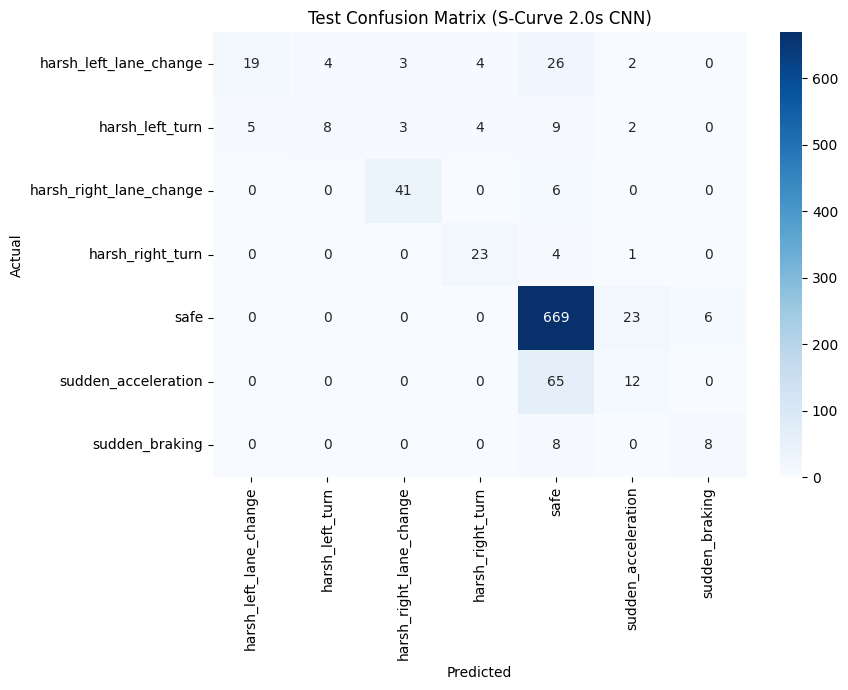

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_loss, test_f1, y_true_test, y_pred_test = evaluate(model, test_loader)
print("\n--- Test Classification Report ---")
print(classification_report(y_true_test, y_pred_test, target_names=label_order, digits=4, zero_division=0))

cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix (S-Curve 2.0s CNN)')
plt.tight_layout()
plt.show()


## 11. Save CNN Model Bundle
Save model parameters, scaler, features, and configuration to be loaded by the real-time simulation detector.

In [13]:
bundle_path = ARTIFACT_DIR / "harsh_event_cnn_bundle.pth"
bundle = {
    "model_state_dict": best_state if best_state is not None else model.state_dict(),
    "scaler": scaler,
    "label_encoder_classes": label_order,
    "feature_cols_stream": feature_cols_stream,
    "window_size": window_size,
    "step_size": step_size,
    "min_event_ratio": 0.5,
    "in_features": F,
    "n_classes": len(label_order),
}
torch.save(bundle, bundle_path)
print("Saved bundle to:", bundle_path)


Saved bundle to: ../artifacts/harsh_event_cnn_bundle.pth
